# COGS 108 - Exploring the Relationship between Parental Factors and How it Affects Student Performance in School

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Ryan Hung
- Hunter Cheng
- Vivian To
- Melissa Vu
- William Zhao

# Abstract
Our project focuses on analyzing the relationships between parental involvement and student success. Because our own parents have played a large role in our pursuit of education, we wanted to see if the same influence extended towards the general population. As such, this project analyzes the effects of certain parental involvement factors such as level of education, job, family size, and etc on student academic performance (grades, absences, failures).

We accomplished this project using various data science techniques on a dataset containing student and parent information from two Portuguese grade schools. We employed Python, and mainly worked with the `Pandas`, `NumPy`, and `Scipy` packages to perform our analyses. After our thorough analysis, we found that parental occupation and education were statistically strong influences on student grades.

# Research Question

What parental factors (time spent at home, education, income, etc) affect student performance (grades, failures, absences) the most?

## Background and Prior Work

Parents play a large role in shaping the lives of their children. Several parental factors are key to child upbringing. For instance, a parent’s financial status can influence multiple aspects of their child’s life. Our group would like to explore how parental involvement can affect student performance in school.

In the research paper “The Longitudinal Process of Early Parent Involvement on Student Achievement: A Path Analysis,”<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) a study was conducted in which 1,539 racial minority children who attended a Child-Parent Center (CPC) pre-kindergarten program was compared to 550 students in the same area but who did not attend the same program. The CPC encourages parents to participate at least half a day per week in the program, and a unique feature is the Parent Resource Room, fostering educational activities, parent interactions, and parent-child engagement. The study calculated Pearson correlation between variables such as level of parent involvement, number of years in CPC, and level of motivation with student grades, and all yielded a p-value ~0, suggesting that there is significant statistical evidence that parent involvement has a strong impact on grades. This is because when parents are involved in their children’s academic education, they are more likely to cultivate a child’s love for learning by being proactive and engaging with their work as well as teachers. However, parenting style could also affect this outcome. According to the Research paper: Longitudinal Relations Among Parenting Styles, Prosocial Behaviors, and Academic Outcomes in U.S. Mexican Adolescents<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2), where the researchers compared two kinds of parents: authoritarian parents (high on demand and responsiveness), and neglectful parents (high on demand and low on responsiveness), the differentiation factor of responsiveness contributed to the academic outcome of their children. Therefore, the researchers concluded that parents' responsiveness is positively correlated with children’s academic performance. 

1. <a name="cite_note-1"></a> [^](#cite_ref-1) https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5115270/ 
2. <a name="cite_note-2"></a> [^](#cite_ref-2) https://pubmed.ncbi.nlm.nih.gov/28213904/

# Hypothesis


Children who experience higher levels of parental involvement, such as regular communication between parents and teachers, participation in parent-teacher meetings, assistance with homework, and engagement in educational activities at home, will achieve, on average, higher grades. Out of several factors, we hypothesize that parents who have higher education will positively impact their children’s grades the most because these parents are likely to impart their educational values to their children and put more effort into being involved.

# Data
We require variables that measure child academic performance and also parental status. For instance, we would need test scores or grades of a student. For that specific student, we would also require the education and economic status of the parent. As such, tidy row-wise formatting is necessary where each row corresponds to a child-parent pair. To encourage a more rich analysis, we would ideally want > 1000 child-parent pairs. We would also ideally have more granular data for students in different academic grades and also schools.

- https://www.kaggle.com/datasets/devansodariya/student-performance-data

## Data overview

For each dataset include the following information
- Dataset #1
  - Dataset Name: Student Performance Dataset
  - Link to the dataset: https://www.kaggle.com/datasets/devansodariya/student-performance-data?resource=download
  - Number of observations: 395
  - Number of variables: 33

The dataset above describes student achievement in secondary education of two Portuguese schools. It comes from two classes, mathematics and Portuguese language. Though typical projects near ~1k observations, we believe this dataset contains a plethora of variables that we can analyze to offset the smaller observation count. Because our project focuses on parental involvement, a couple columns are of interest to us:
1. famsize - family size (binary: 'LE3' - less or equal to 3 or 'GT3' - greater than 3)
2. Pstatus - 	parent's cohabitation status (binary: 'T' - living together or 'A' - apart)
3. Medu -	mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2: 5th to 9th grade, 3: secondary education or 4: higher education)
4. Fedu - father's education (numeric: 0 - none, 1 - primary education (4th grade), 2: 5th to 9th grade, 3: secondary education or 4: higher education)
5. Mjob - mother's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')
6. Fjob -	father's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')
7. guardian - student's guardian (nominal: 'mother', 'father' or 'other')
8. famrel	- quality of family relationships (numeric: from 1 - very bad to 5 - excellent)
9. grades - G1, G2, and G3 correspond to students' first period, second period, and final grades respectively; numeric

We chose to highlight these columns because they pertain to parental status/involvement while also giving us a measure of a student's academic performance.

---
### Data Cleaning Summary
We have taken out a few of the columns that are not observations that will be included in our main focus. This includes nursery, reason for going to school, romantic relationships, amount of time going out, health, extra classes, travel time, whether paid, and free time. We have also excluded the rows that do not have parent status as together since our hypothesis involves mainly parents that are still together. We have also converted some strings to numbers for easier data manipulation in the future. Aside from these tasks, our data was fairly clean with no NaNs or missing values. Our next steps will be to apply log transformations in order to normalize the data, making sure that each of our categorical variables will be more uniform and ready for visualizations. The top factors to test out will be parental education, job, and other socioeconomic factors related to our question. We will utilize regression analysis, correlation, and run predictive modeling to assess these results.

# Student Performance Dataset

In [1]:
# import dependencies and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

pd.option_context('mode.use_inf_as_na', True)

data_path = os.path.join(os.getcwd(), 'data', 'student_data.csv')
students = pd.read_csv(data_path)

In [2]:
pd.set_option('display.max_columns', None) 
students.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [3]:
students.shape

(395, 33)

In [4]:
students.dropna(inplace=True) # drop rows with missing data

In [5]:
students.shape # no rows had missing data

(395, 33)

In [6]:
# Drop the columns that are not useful for the question at the hand
students = students.drop(columns=['Dalc','Walc','romantic','goout','health','paid','traveltime','freetime','nursery', 'school'])
students = students[students['Pstatus'] != 'A']

In [7]:
students.shape

(354, 23)

In [8]:
students.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,studytime,failures,schoolsup,famsup,activities,higher,internet,famrel,absences,G1,G2,G3
1,F,17,U,GT3,T,1,1,at_home,other,course,father,2,0,no,yes,no,yes,yes,5,4,5,5,6
2,F,15,U,LE3,T,1,1,at_home,other,other,mother,2,3,yes,no,no,yes,yes,4,10,7,8,10
3,F,15,U,GT3,T,4,2,health,services,home,mother,3,0,no,yes,yes,yes,yes,3,2,15,14,15
4,F,16,U,GT3,T,3,3,other,other,home,father,2,0,no,yes,no,yes,no,4,4,6,10,10
5,M,16,U,LE3,T,4,3,services,other,reputation,mother,2,0,no,yes,yes,yes,yes,5,10,15,15,15


In [9]:
students['famsize'] = students['famsize'].map({'GT3': 1, 'LE3': 0}) # map all binary columns to 1 and 0
students['sex'] = students['sex'].map({'F': 1, 'M': 0})
students['address'] = students['address'].map({"U": 0, "R": 1})
students['Pstatus'] = students['Pstatus'].map({"T": 0, "A": 1})

yes_no_cols = ['schoolsup', 'famsup', 'activities', 'higher', 'internet']
for col in yes_no_cols:
    students[col] = students[col].map({'yes': 1, 'no': 0})

In [10]:
students.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,studytime,failures,schoolsup,famsup,activities,higher,internet,famrel,absences,G1,G2,G3
1,1,17,0,1,0,1,1,at_home,other,course,father,2,0,0,1,0,1,1,5,4,5,5,6
2,1,15,0,0,0,1,1,at_home,other,other,mother,2,3,1,0,0,1,1,4,10,7,8,10
3,1,15,0,1,0,4,2,health,services,home,mother,3,0,0,1,1,1,1,3,2,15,14,15
4,1,16,0,1,0,3,3,other,other,home,father,2,0,0,1,0,1,0,4,4,6,10,10
5,0,16,0,0,0,4,3,services,other,reputation,mother,2,0,0,1,1,1,1,5,10,15,15,15


In [11]:
students.describe() # describe numerical data

,sex,age,address,famsize,Pstatus,Medu,Fedu,studytime,failures,schoolsup,famsup,activities,higher,internet,famrel,absences,G1,G2,G3
count,354.000000,354.000000,354.000000,354.000000,354.0,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000
mean,0.522599,16.709040,0.228814,0.734463,0.0,2.703390,2.488701,2.042373,0.333333,0.124294,0.615819,0.525424,0.946328,0.841808,3.951977,5.341808,10.889831,10.661017,10.324859
std,0.500196,1.258435,0.420664,0.442244,0.0,1.116266,1.083556,0.852200,0.738781,0.330383,0.487089,0.500060,0.225689,0.365438,0.871623,7.207889,3.315644,3.738371,4.611121
min,0.000000,15.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,0.000000,16.000000,0.000000,0.000000,0.0,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,4.000000,0.000000,8.000000,9.000000,8.000000
50%,1.000000,17.000000,0.000000,1.000000,0.0,3.000000,2.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,4.000000,3.000000,11.000000,11.000000,11.000000
75%,1.000000,18.000000,0.000000,1.000000,0.0,4.000000,3.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,1.000000,22.000000,1.000000,1.000000,0.0,4.000000,4.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,56.000000,19.000000,19.000000,20.000000


<Axes: xlabel='absences', ylabel='Count'>

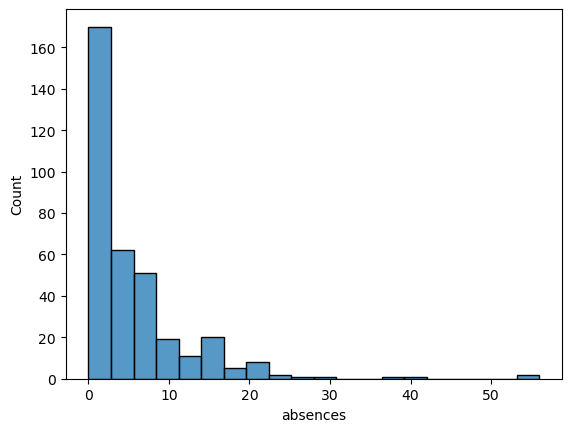

In [12]:
sns.histplot(students['absences'], bins=20) # observe an outlier in the number of absences, but can't remove due uncertainty of underlying data generation process

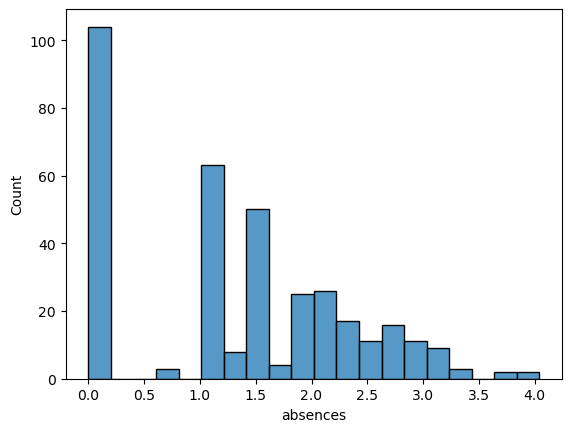

In [13]:
students['absences'] = np.log1p(students['absences']) # log transform the right-skewed absences column
sns.histplot(students['absences'], bins=20) # observe an outlier in the number of absences, but can't remove due uncertainty of underlying data generation process
plt.show()

In [14]:
print("Number of unique values per column:")
for col in students.columns: # Print number of unique values
    print(f"{col}: {students[col].nunique()}")

Number of unique values per column:
sex: 2
age: 8
address: 2
famsize: 2
Pstatus: 1
Medu: 5
Fedu: 5
Mjob: 5
Fjob: 5
reason: 4
guardian: 3
studytime: 4
failures: 4
schoolsup: 2
famsup: 2
activities: 2
higher: 2
internet: 2
famrel: 5
absences: 30
G1: 16
G2: 17
G3: 18


# Results

## Exploratory Data Analysis

### Section 1 of EDA - Relationship between parent education and student grades

In [15]:
# (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
students_1 = students.copy()
students_1.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,studytime,failures,schoolsup,famsup,activities,higher,internet,famrel,absences,G1,G2,G3
1,1,17,0,1,0,1,1,at_home,other,course,father,2,0,0,1,0,1,1,5,1.609438,5,5,6
2,1,15,0,0,0,1,1,at_home,other,other,mother,2,3,1,0,0,1,1,4,2.397895,7,8,10
3,1,15,0,1,0,4,2,health,services,home,mother,3,0,0,1,1,1,1,3,1.098612,15,14,15
4,1,16,0,1,0,3,3,other,other,home,father,2,0,0,1,0,1,0,4,1.609438,6,10,10
5,0,16,0,0,0,4,3,services,other,reputation,mother,2,0,0,1,1,1,1,5,2.397895,15,15,15


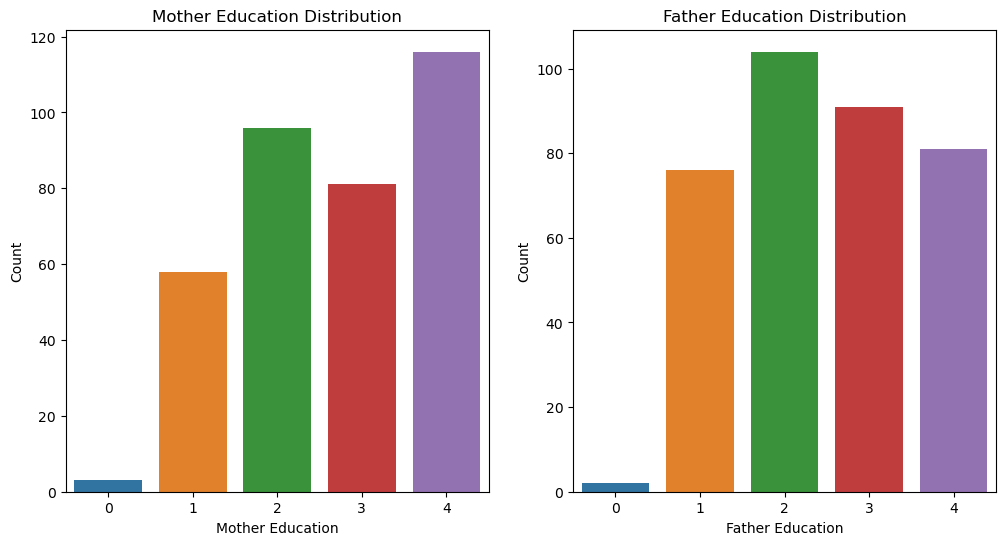

In [16]:
# Show Distribution of Parent Education
fig, axs = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Bar plot for Medu
sns.countplot(x=students_1['Medu'], ax=axs[0])
axs[0].set_xlabel('Mother Education')
axs[0].set_ylabel('Count')
axs[0].set_title('Mother Education Distribution')

#Bar plot for Fedu
sns.countplot(x=students_1['Fedu'], ax=axs[1])
axs[1].set_xlabel('Father Education')
axs[1].set_ylabel('Count')
axs[1].set_title('Father Education Distribution')

plt.show()

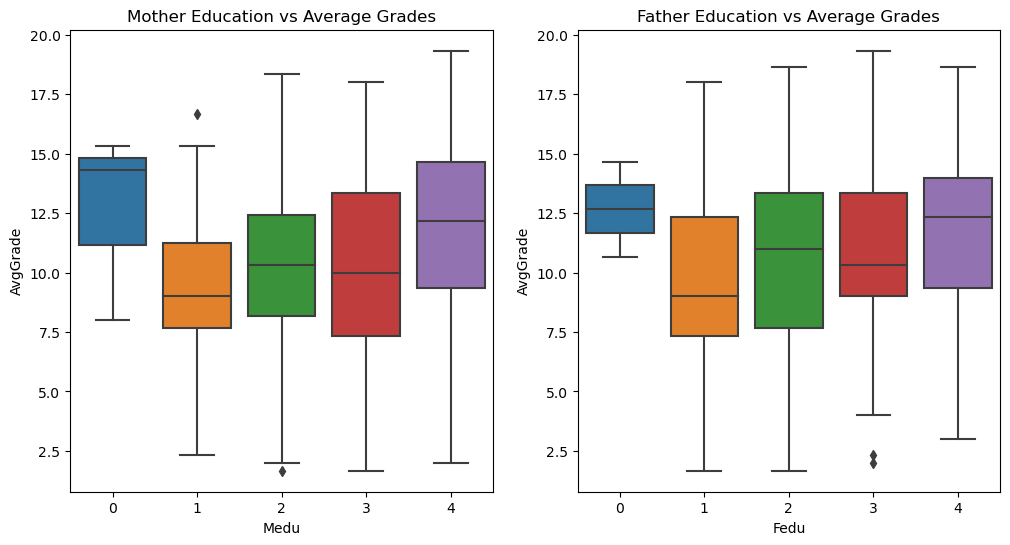

In [17]:
# Parent Education to Average grade
students_1['AvgGrade'] = students_1[['G1', 'G2', 'G3']].mean(axis=1)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Mother Education Boxplot
sns.boxplot(x='Medu', y='AvgGrade', data=students_1, ax=axs[0])
axs[0].set_title('Mother Education vs Average Grades')

# Father Education boxplot
sns.boxplot(x='Fedu', y='AvgGrade', data=students_1,  ax=axs[1])
axs[1].set_title('Father Education vs Average Grades')

plt.show()

It seems that the distributions for mother eduction for values 1-4 are similar with slight variations and the same is obeserved for father education. The odd observation is the mother education and father education values at 0 show a very short boxplot. This may be due to a limited number of values associated with them. So I will need to determine if they need to be removed from further analysis. There were also some outliers found in the boxplots for mother education at values 1 and 2 and for fathre education at value 3. These outliers are due to certain students performing significantly better or worse compared to other students for those parent education levels.

In [18]:
import scipy.stats as stats
medu_0 = students_1.loc[students_1['Medu'] == 0, 'AvgGrade']
medu_1 = students_1.loc[students_1['Medu'] == 1, 'AvgGrade']
medu_2 = students_1.loc[students_1['Medu'] == 2, 'AvgGrade']
medu_3 = students_1.loc[students_1['Medu'] == 3, 'AvgGrade']
medu_4 = students_1.loc[students_1['Medu'] == 4, 'AvgGrade']

fedu_0 = students_1.loc[students_1['Fedu'] == 0, 'AvgGrade']
fedu_1 = students_1.loc[students_1['Fedu'] == 1, 'AvgGrade']
fedu_2 = students_1.loc[students_1['Fedu'] == 2, 'AvgGrade']
fedu_3 = students_1.loc[students_1['Fedu'] == 3, 'AvgGrade']
fedu_4 = students_1.loc[students_1['Fedu'] == 4, 'AvgGrade']

print(len(medu_0) , len(fedu_0))
print(len(medu_1) , len(fedu_1))
print(len(medu_2) , len(fedu_2))
print(len(medu_3) , len(fedu_3))
print(len(medu_4) , len(fedu_4))
# medu_0 and fedu_0 have a few points compared to the rest of the other points so remove from analysis

3 2
58 76
96 104
81 91
116 81


Mother and father education at values 0 have very few points compared to the other education values, so they will be removed from further analysis.

In [19]:
_,p_value = stats.f_oneway(medu_1, medu_2, medu_3, medu_4)
print("P-value:", p_value)

_, p_value = stats.f_oneway(fedu_1, fedu_2, fedu_3, fedu_4)
print("P-value:", p_value)

P-value: 5.315957914263279e-06
P-value: 0.0035776986041636196


# Summary - Parent Education vs Students Grades #

The one-way Anova tests found that there was anough evidence to show that each parent's education does affect their student's average grade since the p-values were 5.3160e-06 and 0.0036 for mother education and father education, respectively. This supports my thoughts on the effects of parent education on student grades. I believe that a parent having a higher education will value working hard to achieve good grades in school and would apply those values on their children to work hard and be studious. 

### Section 2 of EDA - Relationship between parent job and student grades

In [20]:
students_2 = students.copy()
students_2.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,studytime,failures,schoolsup,famsup,activities,higher,internet,famrel,absences,G1,G2,G3
1,1,17,0,1,0,1,1,at_home,other,course,father,2,0,0,1,0,1,1,5,1.609438,5,5,6
2,1,15,0,0,0,1,1,at_home,other,other,mother,2,3,1,0,0,1,1,4,2.397895,7,8,10
3,1,15,0,1,0,4,2,health,services,home,mother,3,0,0,1,1,1,1,3,1.098612,15,14,15
4,1,16,0,1,0,3,3,other,other,home,father,2,0,0,1,0,1,0,4,1.609438,6,10,10
5,0,16,0,0,0,4,3,services,other,reputation,mother,2,0,0,1,1,1,1,5,2.397895,15,15,15


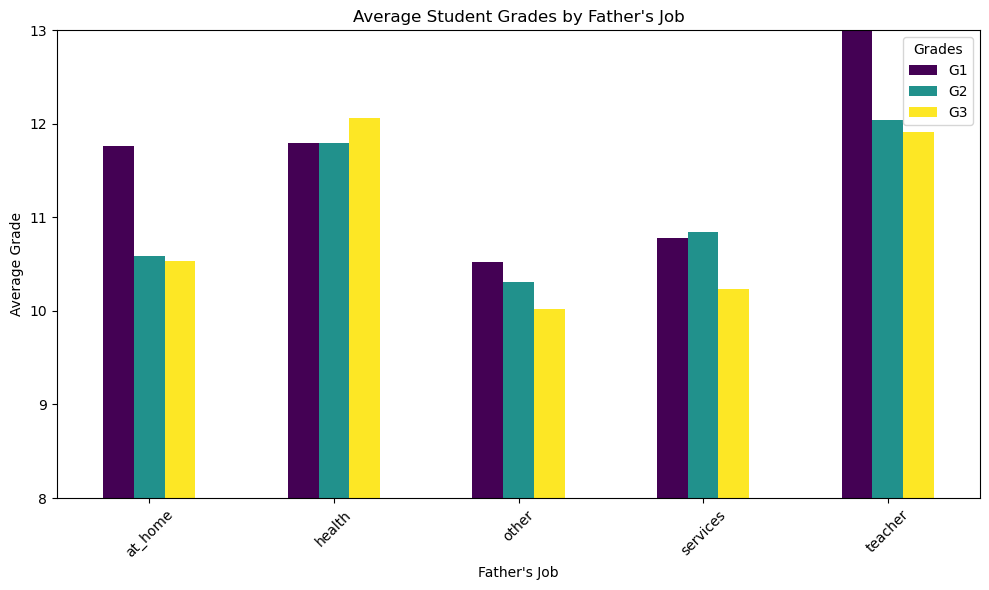

In [21]:
#FATHER'S JOB TO AVERAGE GRADE OF STUDENTS

#Group average grade of students by father's job
father_job_grades = students_2.groupby('Fjob')[['G1', 'G2', 'G3']].mean()

#Bar plot for average grade of students to father's job
father_job_grades.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.ylim(8,13)
plt.title('Average Student Grades by Father\'s Job')
plt.xlabel('Father\'s Job')
plt.ylabel('Average Grade')
plt.xticks(rotation=45)
plt.legend(title='Grades')
plt.tight_layout()
plt.show()


It appears that the distribution of average student grades to father's job is roughly equal. There are no extreme outliers in this case involving students whose father's job has a significant impact on their academic performance. However, we do see that students with fathers who are teachers receive a noticeably higher "G1" grade (>12), than students whose fathers do not work as teachers.

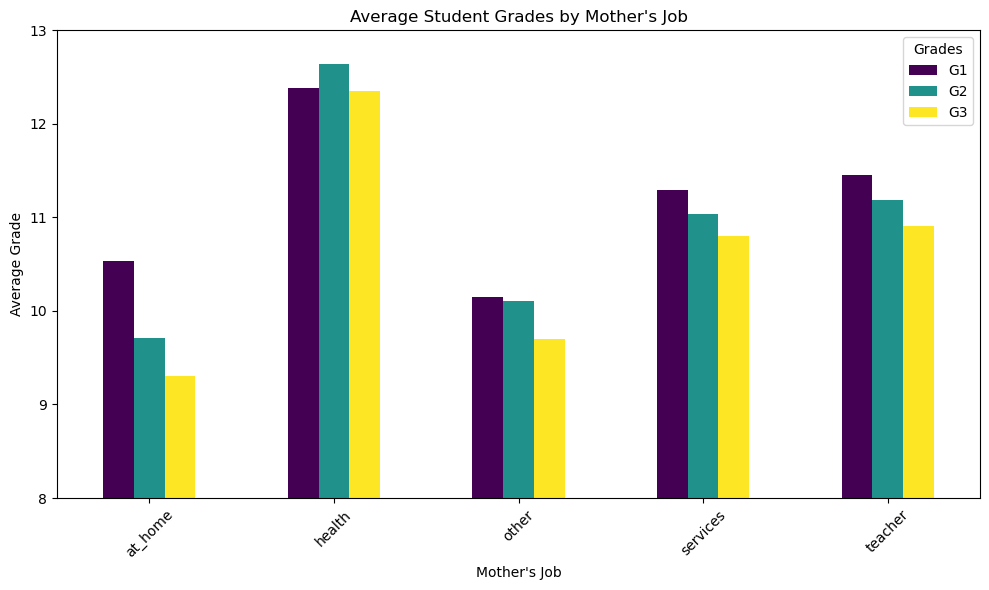

In [22]:
#MOTHER'S JOB TO AVERAGE GRADE OF STUDENTS

#Group average grade of students by father's job
mother_job_grades = students_2.groupby('Mjob')[['G1', 'G2', 'G3']].mean()

#Bar plot for average grade of students to mother's job
mother_job_grades.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.ylim(8,13)
plt.title('Average Student Grades by Mother\'s Job')
plt.xlabel('Mother\'s Job')
plt.ylabel('Average Grade')
plt.xticks(rotation=45)
plt.legend(title='Grades')
plt.tight_layout()
plt.show()

The distribution of student grades to mother's job is roughly equal throughout. We do see a slight increase of grades in students whose mother's job is health (~>3-4 higher) than the other job types. However, for mothers, we see that students with mothers as teachers do not have the highest grade in this case in comparison to students with fathers that are teachers.

In [23]:
grouped_data_mother = students.groupby('Mjob')['G3'].apply(list).tolist()
grouped_data_father = students.groupby('Fjob')['G3'].apply(list).tolist()

# Run ANOVA test for mother's job
_, p_value_mother = stats.f_oneway(*grouped_data_mother)
print("P-value (Mother's Job):", p_value_mother)

# Run ANOVA test for father's job
_, p_value_father = stats.f_oneway(*grouped_data_father)
print("P-value (Father's Job):", p_value_father)

P-value (Mother's Job): 0.011347248595241175
P-value (Father's Job): 0.2073196089629894


As a result of the p-values collected from performing a one-way Anova test, we can see that the p-value for the mother's job to student grade is 0.0113 and the p-value for father's job to student grade is 0.2073, respectively. This means that the p-value for the mother's job is less than the conventional significance level of 0.05, while the p-value for the father's job is significantly higher. As such, we reject our null hypothesis when it comes to the affect of the mother's job on student performance, meaning that there is an effect on student grades, and we fail to reject the null hypothesis of the father's job on student performance, meaning there is no significant effect on student grades.

# Summary - Student grade to parent's job analysis #

At first, I thought it would make sense for students with a parent as a teacher to have noticeably higher grades than students with parents who work as a different job type. This was under my assumption that students with teacher parents would be more engaged with their child's work as they are teachers themselves and want to make sure their kid is on track with their work.

However, after visualizing the data and categorizing the students' average grade by job occupation of each parent, we can see that only students with fathers as teachers and students with mothers in health produce a slightly higher grade average than students with fathers and mothers not in those job occupations. We do see a slight correlation between parents in the health and teacher sector of jobs, as students with parents in these sectors overall receieve a higher grade distribution in comparison to students with parents working at home, services, or in other.


### Section 3 of EDA - Relationship between parent status/family size and effect on student grades

In [24]:
students_3 = students.copy()
students_3.head()

#use family size 'famsize' and parent status 'pstatus'.
#use student grades calculation as measurement. g1 g2 g3

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,studytime,failures,schoolsup,famsup,activities,higher,internet,famrel,absences,G1,G2,G3
1,1,17,0,1,0,1,1,at_home,other,course,father,2,0,0,1,0,1,1,5,1.609438,5,5,6
2,1,15,0,0,0,1,1,at_home,other,other,mother,2,3,1,0,0,1,1,4,2.397895,7,8,10
3,1,15,0,1,0,4,2,health,services,home,mother,3,0,0,1,1,1,1,3,1.098612,15,14,15
4,1,16,0,1,0,3,3,other,other,home,father,2,0,0,1,0,1,0,4,1.609438,6,10,10
5,0,16,0,0,0,4,3,services,other,reputation,mother,2,0,0,1,1,1,1,5,2.397895,15,15,15


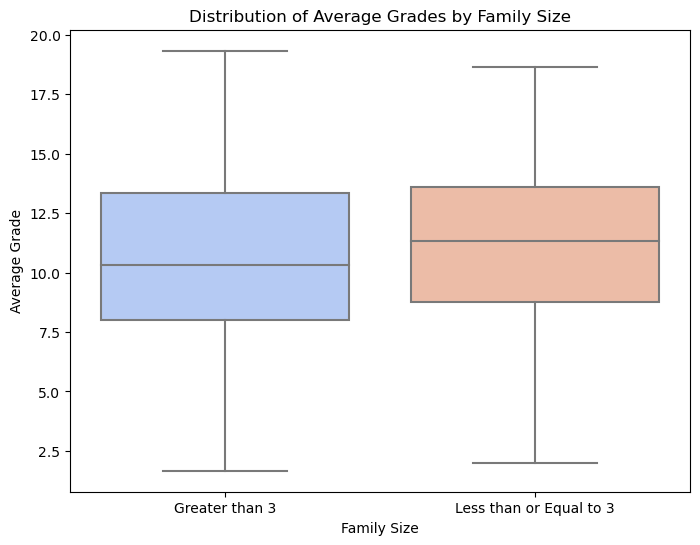

In [25]:
#FAMILY SIZE to AVERAGE GRADE

# Calculate the AvgGrade
students_3['AvgGrade'] = students_3[['G1', 'G2', 'G3']].mean(axis=1)
students_3['famsize'] = students_3['famsize'].map({0: 'Less than or Equal to 3', 1: 'Greater than 3'})

# Box Plot for Average Grades vs. Mapped Family Size
plt.figure(figsize=(8, 6))
sns.boxplot(x='famsize', y='AvgGrade', data=students_3, palette='coolwarm')
plt.title('Distribution of Average Grades by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Average Grade')
plt.show()

The distributions of average grades categorized by larger and smaller family sizes seem to be generally equal. Though, it seems that smaller family sizes have children who earn a slightly higher average grade.

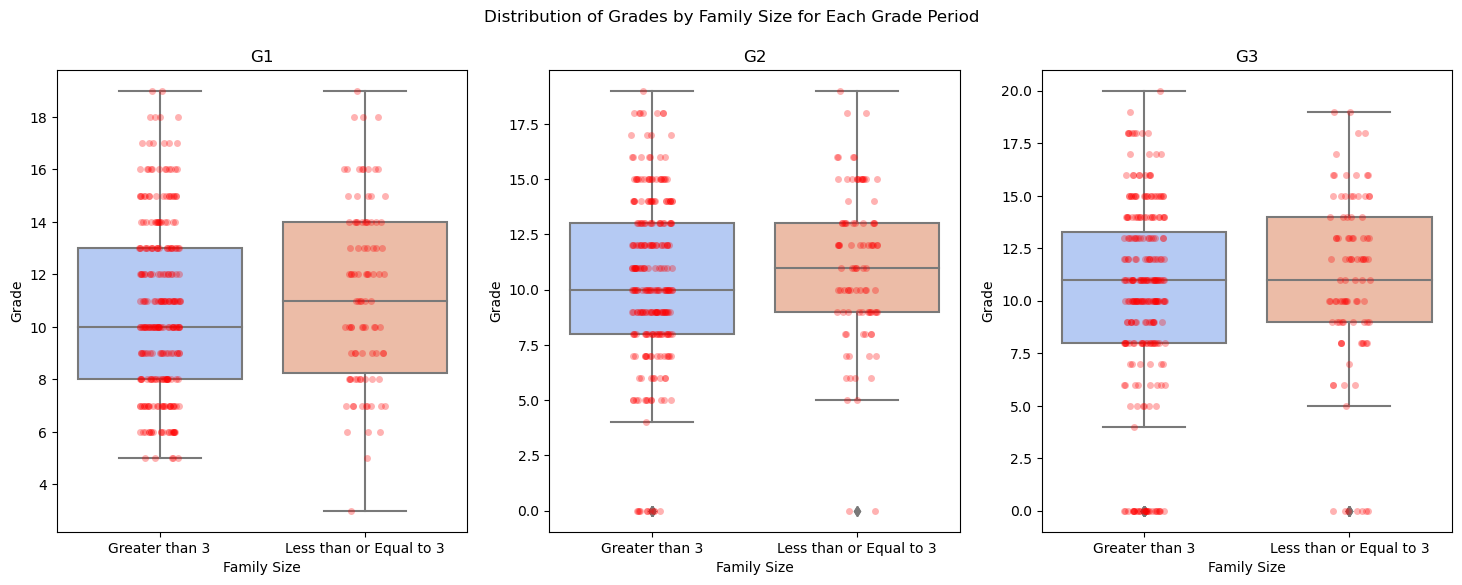

In [26]:
# Each plot represents a grading period
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) 
fig.suptitle('Distribution of Grades by Family Size for Each Grade Period')

# change color for stripplot as neccesary
stripplot_color = 'red'  

# Plot for G1 
sns.boxplot(ax=axes[0], x='famsize', y='G1', data=students_3, palette='coolwarm')
sns.stripplot(ax=axes[0], x='famsize', y='G1', data=students_3, color=stripplot_color,jitter = True, alpha=0.3)
axes[0].set_title('G1')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Grade')

# G2
sns.boxplot(ax=axes[1], x='famsize', y='G2', data=students_3, palette='coolwarm')
sns.stripplot(ax=axes[1], x='famsize', y='G2', data=students_3, color=stripplot_color, jitter=True, alpha= 0.3)
axes[1].set_title('G2')
axes[1].set_xlabel('Family Size')
axes[1].set_ylabel('Grade')

# G3
sns.boxplot(ax=axes[2], x='famsize', y='G3', data=students_3, palette='coolwarm')
sns.stripplot(ax=axes[2], x='famsize', y='G3', data=students_3, color=stripplot_color, jitter=True, alpha=0.3)
axes[2].set_title('G3')
axes[2].set_xlabel('Family Size')
axes[2].set_ylabel('Grade')

plt.show()


Grades are more granular in the dataset. The average grade plotted above was engineered. As such, plotting the individual period grades and final grades by family sizes yields slightly different distributions.
However, none of them stand out as drastically different.

In [27]:

#T Test for Fam Size
le3 = students_3[students_3['famsize'] == 'LE3']['AvgGrade']
gt3 = students_3[students_3['famsize'] == 'GT3']['AvgGrade']

t_stat, p_value = stats.ttest_ind(le3, gt3, equal_var=False) 
print("T-test for average grades by family size:")
print("T-statistic:", t_stat)
print("P-value:", p_value,"\n")
#T Test for each of the periods

for grade in ['G1', 'G2', 'G3']:
    # Extract grades for each family size category
    le3_grades = students_3[students_3['famsize'] == 'LE3'][grade]
    gt3_grades = students_3[students_3['famsize'] == 'GT3'][grade]
    
    # Perform the T-test
    t_stat, p_value = stats.ttest_ind(le3_grades, gt3_grades, equal_var=False)  # Assuming unequal variances
    
    # Print the results
    print(f"T-test for {grade} by family size:")
    print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.3f}\n")

T-test for average grades by family size:
T-statistic: nan
P-value: nan 

T-test for G1 by family size:
T-statistic: nan, P-value: nan

T-test for G2 by family size:
T-statistic: nan, P-value: nan

T-test for G3 by family size:
T-statistic: nan, P-value: nan



Using a two-sample difference of means test, the null hypothesis fails to be rejected, as we do not have sufficient enough evidence to show that the distribution of grades are different given family size.

In [28]:
# identify columns with 0s
def mark_zero_columns(row):
    zero_columns = [col for col in ['G1', 'G2', 'G3'] if row[col] == 0]
    return ', '.join(zero_columns)

# Access function
students_3['ZeroColumn'] = students_3.apply(mark_zero_columns, axis=1)

# Filter rows where at least one grade is 0
rows_with_zeros = students_3[students_3['ZeroColumn'] != '']

rows_with_zeros['ZeroColumn'].value_counts()

G3        24
G2, G3    12
Name: ZeroColumn, dtype: int64

An interesting observation is that of students who achieved a grade of 0, it was always the second, the third, or both G2 and G3 

In [29]:
#parental status is all 0s
set(students_3['Pstatus'])

{0}

# Summary - Family Size vs Grades #

I was unable to work witih Pstatus data, as there was only one unique value the whole time. But, for family size, I made plots across all the periods, as well as across an average calculated across each period. I combined a strip plot and a box plot, to show where individual data points were scattered as well as the statistics of median, quartiles, and range with the box plot.

I found that there were quite a few 0 values for G2 and G3, but never for G1. This is most likely that a student dropped out of the class and didn't receive a grade after the first period, or the second. Some only had their second period missing, some only third, meaning they simply skipped a period of school grades

In summary, after performing t tests on the average, as well as each of the periods, I found none of them to have statistically significant t test statistics or p values. None of these showed that there was enough evidence of a difference between the data, so I can conclude that it is insignificant to have family size be an indicator of student's grades.


### Section 4 of EDA - Student failure analysis

In [30]:
# show failure summary
students['failures'].value_counts()

0    279
1     46
2     15
3     14
Name: failures, dtype: int64

This shows the distribution of 0 1 2 and 3 as possible values for student failure.

In [31]:
#describe the type of data in the dataset
students.dtypes

sex             int64
age             int64
address         int64
famsize         int64
Pstatus         int64
Medu            int64
Fedu            int64
Mjob           object
Fjob           object
reason         object
guardian       object
studytime       int64
failures        int64
schoolsup       int64
famsup          int64
activities      int64
higher          int64
internet        int64
famrel          int64
absences      float64
G1              int64
G2              int64
G3              int64
dtype: object

We want to check which columns correlstes with failures the most, thus we can do a correlation matrix and plot the top few from the result.

In [32]:
students_num = students.select_dtypes(include=[np.number])
correlation_matrix = students_num.corr()

# Get the absolute values of correlation coefficients for the 'failures' column
correlation_abs = correlation_matrix['failures'].abs()

# Sort the correlation matrix by absolute values
sorted_correlation_matrix = correlation_matrix.reindex(correlation_abs.sort_values(ascending=False).index)

print(sorted_correlation_matrix['failures'])

failures      1.000000
G3           -0.357024
G1           -0.353886
G2           -0.351820
higher       -0.334141
age           0.275250
Medu         -0.237023
Fedu         -0.225305
studytime    -0.166483
address       0.100269
internet     -0.066455
absences      0.061638
famsup       -0.060354
activities   -0.053677
famrel       -0.045459
sex          -0.043441
schoolsup     0.027081
famsize       0.020231
Pstatus            NaN
Name: failures, dtype: float64


Since G1 G2 and G3 are very similar in correlation coefficient, we can combine them for better efficiency.

In [33]:
#add G1 G2 G3 to get total grade and assign to new column called total_grade
students_num['total_grade'] = students['G1'] + students['G2'] + students['G3']

#normalize the total grade
students_num['total_grade'] = (students_num['total_grade'] - students_num['total_grade'].mean()) / students_num['total_grade'].std()


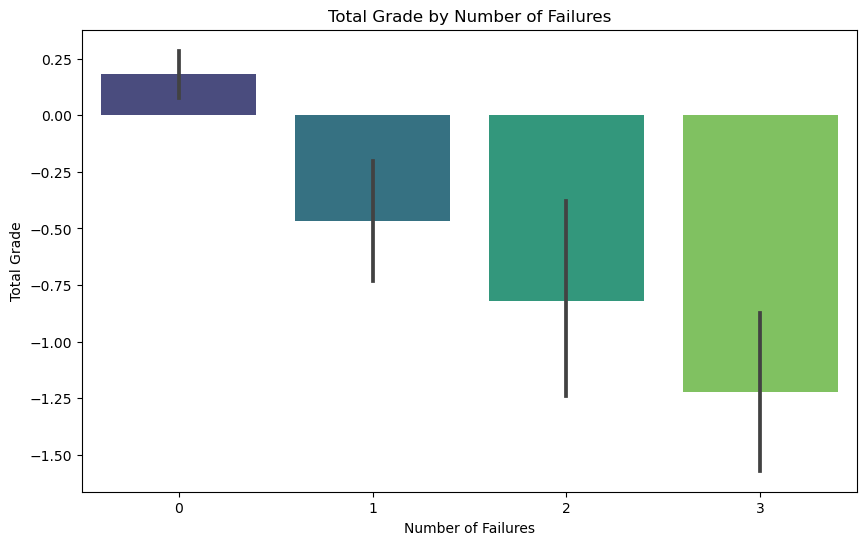

In [34]:
# plot failures against total grade, mark failures =1 as yellow, and failures = 0 as green, failures = 2 as orange, and failures = 3 as red, bar plot withineach failure category
plt.figure(figsize=(10, 6))
sns.barplot(x='failures', y='total_grade', data=students_num, palette='viridis')
plt.title('Total Grade by Number of Failures')
plt.xlabel('Number of Failures')
plt.ylabel('Total Grade')
plt.show()


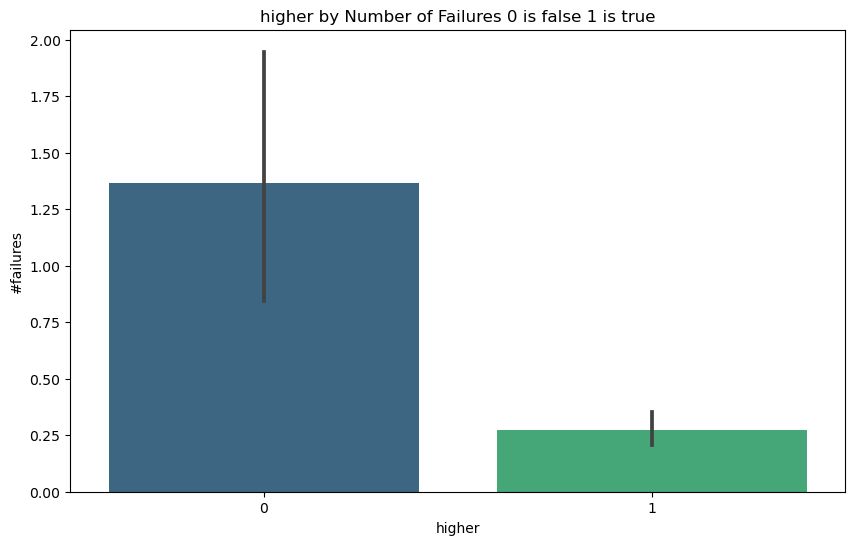

In [35]:
#bar plot for failures against higher.
plt.figure(figsize=(10, 6))
sns.barplot(x='higher', y='failures', data=students_num, palette='viridis')
plt.title('higher by Number of Failures 0 is false 1 is true')
plt.xlabel('higher')
plt.ylabel('#failures')
plt.show()

This shows student willing to pursue higher education has a lower number of failures compare to student not willing to pursue higher education.

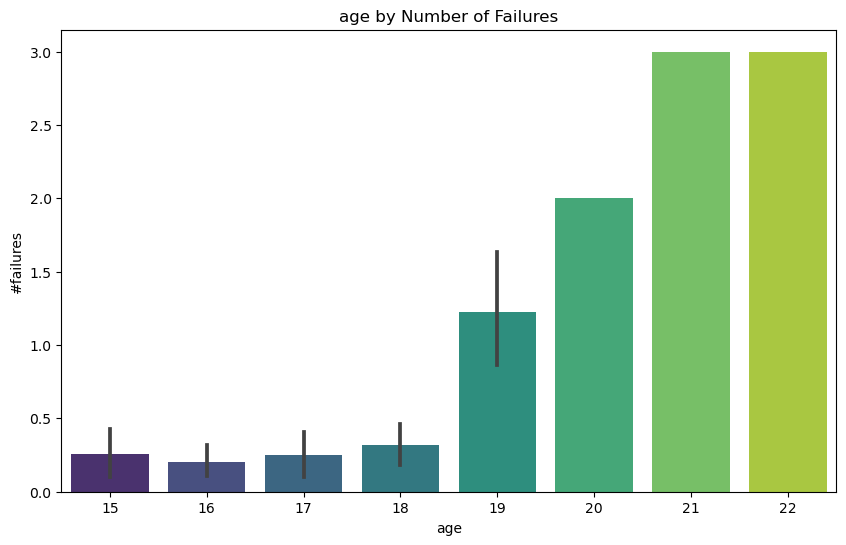

In [36]:
#bar plot for failures against age.
plt.figure(figsize=(10, 6))
sns.barplot(x='age', y='failures', data=students_num, palette='viridis')
plt.title('age by Number of Failures')
plt.xlabel('age')
plt.ylabel('#failures')
plt.show()


This trend is very straight forward, since failure is cummulative, as you grow older you failures will accumulate. 

### Section 5 of EDA - Student absences analysis

In [37]:
students_5 = students.copy()
students_5.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,studytime,failures,schoolsup,famsup,activities,higher,internet,famrel,absences,G1,G2,G3
1,1,17,0,1,0,1,1,at_home,other,course,father,2,0,0,1,0,1,1,5,1.609438,5,5,6
2,1,15,0,0,0,1,1,at_home,other,other,mother,2,3,1,0,0,1,1,4,2.397895,7,8,10
3,1,15,0,1,0,4,2,health,services,home,mother,3,0,0,1,1,1,1,3,1.098612,15,14,15
4,1,16,0,1,0,3,3,other,other,home,father,2,0,0,1,0,1,0,4,1.609438,6,10,10
5,0,16,0,0,0,4,3,services,other,reputation,mother,2,0,0,1,1,1,1,5,2.397895,15,15,15


<Axes: xlabel='absences', ylabel='Count'>

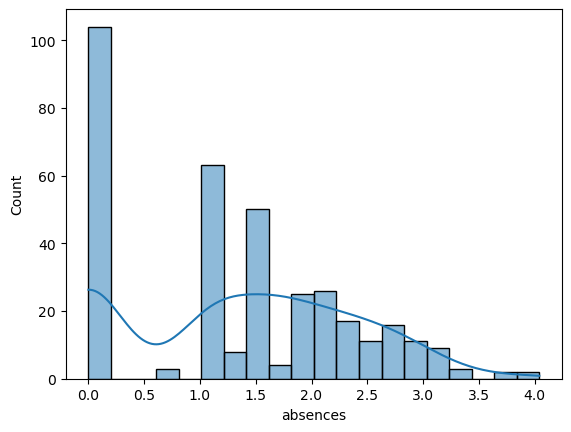

In [38]:
sns.histplot(students_5, x='absences', bins=20, kde=True)

In the data cleaning section, absences was log-transformed because it had a heavy right skew. It seems that most students accumulate little absences.

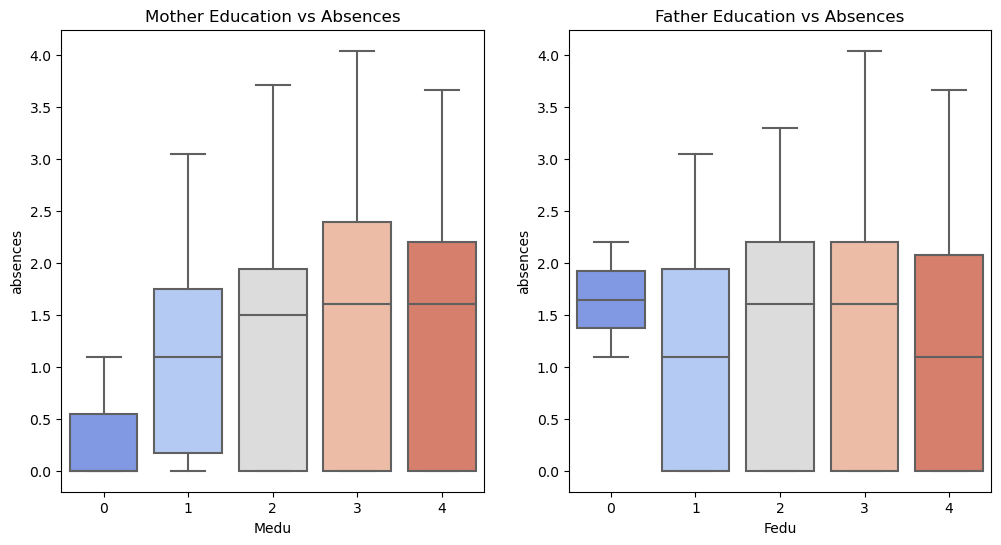

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# First plot
sns.boxplot(x='Medu', y='absences', data=students_5, palette='coolwarm', ax=axes[0])
axes[0].set_title('Mother Education vs Absences')

# Second plot
sns.boxplot(x='Fedu', y='absences', data=students_5, palette='coolwarm', ax=axes[1])
axes[1].set_title('Father Education vs Absences')

plt.show()

It seems that the number of absences can vary slightly given mother and father education. It varies the most when the mother and father have no education.

In [40]:
mother_0_edu = students_5.loc[students_5['Medu'] == 0, 'absences']
father_0_edu = students_5.loc[students_5['Fedu'] == 0, 'absences']

len(mother_0_edu), len(father_0_edu) # low amount of points so remove from analysis

(3, 2)

In [41]:
import scipy.stats as stats

mother_1_edu = students_5.loc[students_5['Medu'] == 1, 'absences']
mother_2_edu = students_5.loc[students_5['Medu'] == 2, 'absences']
mother_3_edu = students_5.loc[students_5['Medu'] == 3, 'absences']
mother_4_edu = students_5.loc[students_5['Medu'] == 4, 'absences']

father_1_edu = students_5.loc[students_5['Fedu'] == 1, 'absences']
father_2_edu = students_5.loc[students_5['Fedu'] == 2, 'absences']
father_3_edu = students_5.loc[students_5['Fedu'] == 3, 'absences']
father_4_edu = students_5.loc[students_5['Fedu'] == 4, 'absences']

_, p_value = stats.f_oneway(mother_1_edu, mother_2_edu, mother_3_edu, mother_4_edu)
print("P-value:", p_value)

_, p_value = stats.f_oneway(father_1_edu, father_2_edu, father_3_edu, father_4_edu)
print("P-value:", p_value)

P-value: 0.5468191173037674
P-value: 0.6662486920156443


Running one-way anova tests yielded insufficient evidence to reject the null. It seems that the average number of absences between mother and father education is roughly the same and can any variation is explainable by random chance alone.

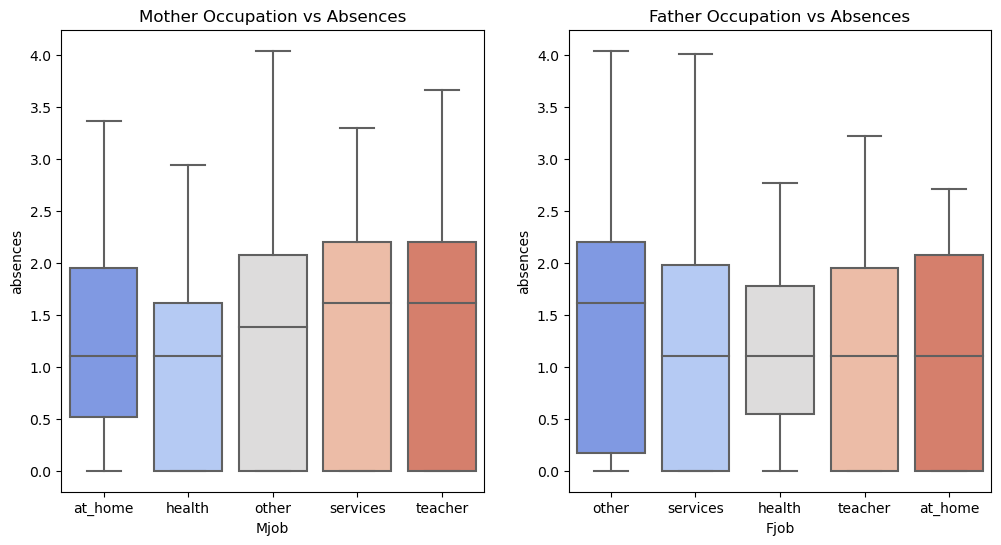

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# First plot
sns.boxplot(x='Mjob', y='absences', data=students_5, palette='coolwarm', ax=axes[0])
axes[0].set_title('Mother Occupation vs Absences')

# Second plot
sns.boxplot(x='Fjob', y='absences', data=students_5, palette='coolwarm', ax=axes[1])
axes[1].set_title('Father Occupation vs Absences')

plt.show()

It seems that mother and father occupation do not affect absences much.

In [43]:
import scipy.stats as stats

mother_jobs = students_5['Mjob'].unique()
father_jobs = students_5['Fjob'].unique()

_, p_value = stats.f_oneway(*[students_5.loc[students_5['Mjob'] == job, 'absences'] for job in mother_jobs])
print("P-value:", p_value)

_, p_value = stats.f_oneway(*[students_5.loc[students_5['Fjob'] == job, 'absences'] for job in father_jobs])
print("P-value:", p_value)

P-value: 0.8368927822687703
P-value: 0.36755828416053526


Running one-way anova tests yielded insufficient evidence to reject the null. It seems that the average number of absences between mother and father occupation is roughly the same and can any variation is explainable by random chance alone.

# Summary - Student absences analysis #

Intuitively, I thought it would make sense for parent education and parent occupation to affect student absences more. Perhaps a parent who has a lower level of education won't see the value of enforcing their child's attendance as much as someone with a higher level of occupation. The same line of reasoning applies to parent occupation.

However, after performing one-way ANOVA tests on both these categorical features and number of absences, the tests failed to reject the null. It seems that parent occupation and education are not good determining factors of a student's absences


### Section 6 of EDA - Student's willingness to higher education analysis

In [44]:
print(students_num['higher'].value_counts())

1    335
0     19
Name: higher, dtype: int64


As we can see here higher is a binary data type

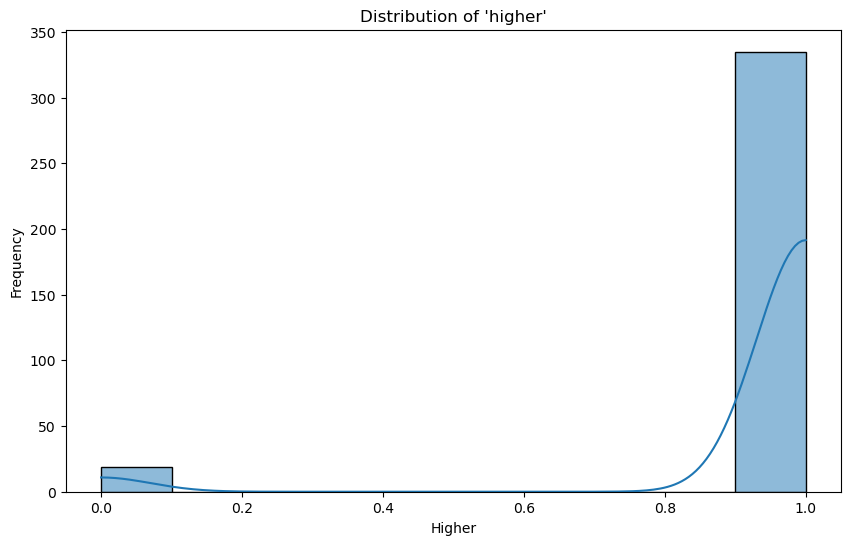

In [45]:
# Plotting the distribution of the "higher" column
plt.figure(figsize=(10, 6))  # Sets the figure size
sns.histplot(data=students_num, x="higher", kde=True)  # Replace "numerical_df" with your actual DataFrame name if it's different
plt.title("Distribution of 'higher'")  # Sets the title of the plot
plt.xlabel("Higher")  # Sets the label for the x-axis
plt.ylabel("Frequency")  # Sets the label for the y-axis
plt.show()  # Displays the plot

As we can see here the distribution of higher is very uneven. Therefore in later correlation analysis we will use Spearman's rank correlation since it is suitable for nonlinear data and data with outliers.

But Firstly Let's plot Distribution of Grades by higher education aspiration to get the general idea

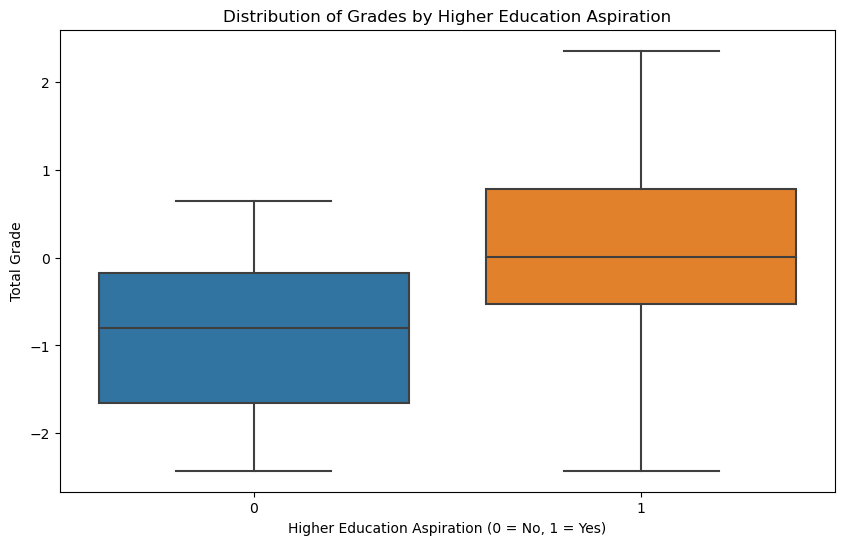

In [46]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='higher', y='total_grade', data=students_num)
plt.title('Distribution of Grades by Higher Education Aspiration')
plt.xlabel('Higher Education Aspiration (0 = No, 1 = Yes)')
plt.ylabel('Total Grade')
plt.show()

As we can see here there is probably a correlation between higher and student's grade, let's run the Spearman's rank correlation analysis to confirm this hypothesis

In [47]:
higher = students_num['higher']
total_grade = students_num['total_grade']

# Calculate Spearman's rank correlation
correlation, p_value = stats.spearmanr(higher, total_grade)

print(f"Spearman's correlation coefficient: {correlation}")
print(f"P-value: {p_value}")

Spearman's correlation coefficient: 0.1859146389827997
P-value: 0.00043761398408981105


As the result shows, we have a low p-valuer of 0.0004 which is way lower than significant level at 0.05 which we can reject the null hypothesis combined with the correlation coefficient we can conclude there is a positive relationship between student's willingness to pursue higher education and the total grade they get.

# Ethics & Privacy

In our data gathering analysis, we must be careful and preserve confidentiality of each child and parent. This is a critical privacy concern that we must address at all steps of our project. We must also be conscious of potential bias in our dataset. If we were to look at schools in different areas, we must be aware of potential economic disparities biasing our analysis.

To avoid ethical and privacy issues, we will start with a thorough dataset search to find data that possesses the least data privacy and ethical issues. We will find a diverse dataset that contains student/parent pairs from multiple ages, racial backgrounds, schools, and locations. If a strong candidate does not appear, we will weigh several factors and decide upon the most diverse dataset we can find.

Furthermore, we will commit to transparency for our ethical framework. We will meticulously highlight and address certain biases inherent in the dataset, such as potential racial or age imbalances. This acknowledgment not only ensures a candid representation of the dataset's limitations but also fosters a responsible and ethical approach to our analysis.


# Discusison and Conclusion

In conclusion, we found that our null hypothesis of parent education having a positive correlation with student performance in school was supported. Out of many parental factors, our data analysis showed that students who had a mother or father with higher education receive better grades in school. This result helped us to answer our research question of what parental factors can significantly impact a student’s academic performance. The p-values of 5.3160e-06 and 0.0036 for mother education and father education, respectively, show that it does positively affect student grades. This could mean that students with parents who have had an education value working hard to achieve good grades in school and would apply those values on their children to be studious.

Another observation was the effect of the parent’s job on student grades. This was another important factor that we did not include in our hypothesis as a factor greatly affecting a student’s performance. However, this helps to answer our research question by adding on to our list of parental factors affecting student performance. We found that students with a mother in healthcare and a father as a teacher receive better grades. In particular, through performing an ANOVA p-value test on these jobs to student grade values, we found the mother’s job plays a more significant role in impacting the student’s performance in school.

Although our findings may show significant p-values for parent education and jobs, may be due to confounding factors. Our dataset was small being less than 1000 students and did not have regional variety. This is due to the data coming from two Portuguese grade schools. Thus, our findings are limited to that of the scope of these two schools.

# Team Contributions

 - Ryan - Structured notebook, section 3 of EDA, abstract
 - Melissa - Section 1 of EDA, wrote project timeline and teamexpectations, part of conclusion
 - Hunter - Data processing, research, wrote Ethics section, Section 5 of EDA
 - Vivian - Section 2 of EDA, conclusion, background
 - William - Section 4 and 6 of EDA, some analysis.